# 🧪 Statistical Tests — When to Use What?
### A Simple Guide for Students

---

> **Goal of this sheet:** You don't need to memorise formulas.
> You just need to know **WHEN** to pick each tool — like a doctor picking the right medicine.

---

## 🎯 First — Understand the p-value (with a real story)

---

### 📖 The Cheating Story

> A student scores **9 out of 10** in an exam.
> The teacher suspects he **cheated**.
> The student says: **"I am innocent. I just studied hard."**

Now — how do we decide who is right?

We ask this question:

> ❓ *"If this student did NOT cheat — what is the chance he would score 9/10 anyway?"*

---

| Situation | What it means |
|-----------|---------------|
| The chance is **HIGH** (e.g. 40%) | Many students score this — no surprise. **Believe the student.** |
| The chance is **VERY LOW** (e.g. 1%) | Almost impossible without cheating. **Suspect cheating.** |

---

### That chance = the **p-value**

```
p-value = probability of seeing this result IF nothing unusual happened
```

### The Decision Rule (always the same):

| p-value | Decision |
|---------|----------|
| **≤ 0.05** | Something unusual IS happening → **Reject H₀** |
| **> 0.05** | Nothing unusual → **Keep H₀** (don't panic) |

---

### H₀ and H₁ — Plain English

| Symbol | Name | Meaning in the story |
|--------|------|----------------------|
| **H₀** | Null hypothesis | *"Student is innocent — the score is just luck/hard work"* |
| **H₁** | Alternative hypothesis | *"Student cheated — the score is suspicious"* |

> 💡 **H₀ is always the boring, normal explanation.**
> H₁ is the surprising claim.

---

C:\Users\Mani\AppData\Local\Temp\ipykernel_9832\1502584284.py:26: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_9832\1502584284.py:26: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mani\AppData\Local\Temp\ipykernel_9832\1502584284.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Mani\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mani\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mani\anaconda3\Lib\site-packa

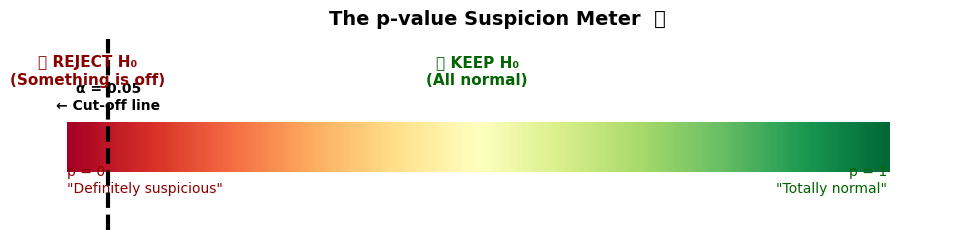

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Simple p-value visual — the "suspicion meter"
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

# Draw gradient bar
for i, x in enumerate(np.linspace(0, 1, 300)):
    color = plt.cm.RdYlGn(x)
    ax.barh(0, 0.0035, left=x, height=0.6, color=color)

# Labels
ax.text(0.0,  -0.55, 'p = 0\n"Definitely suspicious"',  ha='left',   fontsize=10, color='darkred')
ax.text(0.05, 0.45,  'α = 0.05\n← Cut-off line',        ha='center', fontsize=10, color='black', fontweight='bold')
ax.text(1.0,  -0.55, 'p = 1\n"Totally normal"',          ha='right',  fontsize=10, color='darkgreen')
ax.axvline(0.05, color='black', linewidth=3, linestyle='--')

ax.text(0.025, 0.75, '🚨 REJECT H₀\n(Something is off)',   ha='center', fontsize=11, color='darkred',   fontweight='bold')
ax.text(0.5,   0.75, '✅ KEEP H₀\n(All normal)',            ha='center', fontsize=11, color='darkgreen', fontweight='bold')

ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-1, 1.3)
ax.set_title('The p-value Suspicion Meter  🔍', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 🗺️ The Big Picture — Which Test Do I Use?

Ask yourself **two questions**:

1. **What type of data do I have?** (Numbers or Categories?)
2. **What do I want to find out?** (Compare groups? Find relationship? Check shape?)

The table below gives you the answer ↓

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.set_xlim(0, 14); ax.set_ylim(0, 8)

def box(ax, x, y, w, h, text, fc, ec='#333', fs=10, bold=False):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.15', facecolor=fc, edgecolor=ec, linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs,
            fontweight='bold' if bold else 'normal', wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, label, fontsize=8.5, color='#555', ha='center', va='bottom')

# Root
box(ax, 5.5, 6.8, 3, 0.9, '❓ What is my\nquestion?', '#fff9c4', fs=11, bold=True)

# Branch 1 — Is my data normal?
box(ax, 0.2, 5.0, 3, 0.85, '📐 Is my data\nnormally distributed?', '#e3f2fd', bold=True)
arrow(ax, 7, 6.8, 1.7, 5.85, 'check shape first')

box(ax, 0.2, 3.6, 2.2, 0.85, '✅ YES → Normal\nUse Parametric tests', '#c8e6c9')
box(ax, 2.6, 3.6, 2.2, 0.85, '❌ NO → Not Normal\nUse Non-parametric', '#ffccbc')
arrow(ax, 1.7, 5.0, 1.3, 4.45, 'yes')
arrow(ax, 1.7, 5.0, 3.7, 4.45, 'no')

# Branch 2 — Compare groups
box(ax, 5.0, 5.0, 3, 0.85, '👥 Compare\nGroups', '#e8eaf6', bold=True)
arrow(ax, 7, 6.8, 6.5, 5.85)

box(ax, 4.2, 3.6, 1.8, 0.85, '2 Groups\n→ t-test', '#b3e5fc')
box(ax, 6.2, 3.6, 1.8, 0.85, '3+ Groups\n→ ANOVA', '#b3e5fc')
box(ax, 4.2, 2.5, 1.8, 0.85, '2 Groups\n→ Mann-Whitney', '#ffe0b2')
box(ax, 6.2, 2.5, 1.8, 0.85, '3+ Groups\n→ Kruskal-Wallis', '#ffe0b2')
arrow(ax, 6.5, 5.0, 5.1, 4.45, 'normal')
arrow(ax, 6.5, 5.0, 7.1, 4.45, 'normal')
arrow(ax, 5.1, 3.6, 5.1, 3.35)
arrow(ax, 7.1, 3.6, 7.1, 3.35)
ax.text(4.6, 3.2, 'if NOT normal ↓', fontsize=7.5, color='#b55')
ax.text(6.6, 3.2, 'if NOT normal ↓', fontsize=7.5, color='#b55')

# Branch 3 — Relationship
box(ax, 9.5, 5.0, 3, 0.85, '🔗 Relationship\nBetween Variables', '#fce4ec', bold=True)
arrow(ax, 7, 6.8, 11, 5.85)

box(ax, 8.8, 3.6, 2.0, 0.85, 'Both Normal\n→ Pearson r', '#f8bbd0')
box(ax, 11.0, 3.6, 2.0, 0.85, 'Not Normal\n→ Spearman ρ', '#f8bbd0')
box(ax, 8.8, 2.5, 2.0, 0.85, 'Categories\n→ Chi-Square', '#e1bee7')
arrow(ax, 11, 5.0, 9.8, 4.45)
arrow(ax, 11, 5.0, 12.0, 4.45)

ax.set_title('🗺️  Statistical Test Decision Map', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 📋 Each Test — One Line Explanation + Example

---

### 1. 🔔 Normality Test  
*(Shapiro-Wilk)*

**When to use:** Before anything else — check if your numbers follow a bell curve.

| Result | Meaning |
|--------|---------|
| p > 0.05 | Data is **normal** → use parametric tests |
| p ≤ 0.05 | Data is **NOT normal** → use non-parametric tests |

> 🏫 **Example:** Before comparing students' exam marks, check if marks are spread like a bell curve (most students in the middle, few very high or very low).

---

### 2. 👥 t-test  
*(Compare 2 groups, normal data)*

**When to use:** You have **two groups** and want to know if their **averages are different**.

> 🏫 **Example:** Did **boys** and **girls** score differently on the maths test?  
> H₀: "Boys and girls have the same average mark"  
> H₁: "Their averages are different"

---

### 3. 📊 ANOVA  
*(Compare 3+ groups, normal data)*

**When to use:** Like the t-test but for **three or more groups**. (t-test can only handle 2.)

> 🏫 **Example:** Do students in **Class A, Class B, and Class C** score differently?  
> H₀: "All three classes have the same average"  
> H₁: "At least one class is different"

---

### 4. 🥊 Mann-Whitney U  
*(Compare 2 groups, NOT normal data)*

**When to use:** Same job as t-test, but when your data is **skewed or not normal**.

> 🏫 **Example:** Comparing **salaries** of teachers in two schools — salary data is rarely normal (a few very high earners pull the average).

---

### 5. ⚔️ Kruskal-Wallis  
*(Compare 3+ groups, NOT normal data)*

**When to use:** Same job as ANOVA, but when data is **not normal**.

> 🏫 **Example:** Comparing **study hours** across students from 4 different countries — likely skewed data.

---

### 6. 📈 Pearson Correlation  
*(Relationship between two numbers, normal data)*

**When to use:** You want to know if two **numerical** things move together — and data is normal.

| Value | Meaning |
|-------|---------|
| r = +1 | Perfect positive relationship |
| r = 0  | No relationship |
| r = −1 | Perfect negative relationship |

> 🏫 **Example:** Do students who study **more hours** get **higher marks**? (As hours go up, do marks go up too?)

---

### 7. 📉 Spearman Correlation  
*(Relationship between two numbers, NOT normal data)*

**When to use:** Same goal as Pearson but the data is **ranked or not normal**.

> 🏫 **Example:** Does a student's **rank in class** relate to their **rank in sports**? (Ranks = not normal)

---

### 8. 🟦 Chi-Square Test  
*(Relationship between two CATEGORIES)*

**When to use:** Both variables are **categories** (not numbers). You want to know if they are related.

> 🏫 **Example:** Is **gender** (Male/Female) related to **favourite subject** (Maths/Science/Arts)?  
> H₀: "Gender and subject choice are independent — no connection"  
> H₁: "There IS a connection"

---

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Clean summary card visual
tests = [
    ('Shapiro-Wilk\n(Normality)',   'Before everything\nIs data a bell curve?',          'Any numbers',         '#fff9c4'),
    ('t-test',                       'Compare 2 groups\n(normal data)',                   '2 groups, numbers',   '#b3e5fc'),
    ('ANOVA',                        'Compare 3+ groups\n(normal data)',                  '3+ groups, numbers',  '#b3e5fc'),
    ('Mann-Whitney U',               'Compare 2 groups\n(NOT normal)',                    '2 groups, skewed',    '#ffe0b2'),
    ('Kruskal-Wallis',               'Compare 3+ groups\n(NOT normal)',                   '3+ groups, skewed',   '#ffe0b2'),
    ('Pearson r',                    'Relationship between\n2 numbers (normal)',           '2 number columns',    '#f8bbd0'),
    ('Spearman ρ',                   'Relationship between\n2 numbers (NOT normal/ranks)', '2 number/rank cols', '#f8bbd0'),
    ('Chi-Square',                   'Relationship between\n2 categories',                '2 category columns',  '#e1bee7'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (name, when, data_type, color) in zip(axes, tests):
    ax.set_facecolor(color)
    ax.axis('off')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    # Card title
    ax.text(5, 8.8, name, ha='center', va='center', fontsize=12,
            fontweight='bold', color='#222')
    ax.axhline(7.8, color='#aaa', linewidth=1)
    # When to use
    ax.text(0.5, 7.2, '🕐 When:', fontsize=9, color='#555', va='top')
    ax.text(5, 5.8, when, ha='center', va='center', fontsize=10,
            color='#111', multialignment='center')
    ax.axhline(4.2, color='#aaa', linewidth=0.8, linestyle=':')
    # Data type
    ax.text(0.5, 3.7, '📂 Data:', fontsize=9, color='#555', va='top')
    ax.text(5, 2.5, data_type, ha='center', va='center', fontsize=9.5,
            color='#333', multialignment='center', style='italic')
    # Border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#aaa')
        spine.set_linewidth(1.5)

fig.suptitle('📋  Statistical Tests — Quick Reference Cards', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 🧠 Remember Just 3 Questions

Every time you face a statistics problem, ask:

---

### ❓ Question 1: What kind of data do I have?

| Data Type | Example | 
|-----------|---------|  
| **Numbers** | marks, weight, salary, temperature |
| **Categories** | gender, city, pass/fail, subject |

---

### ❓ Question 2: Is my number data normal?

| Situation | What to do |
|-----------|------------|
| Looks like a bell curve | Use **Parametric** tests (t-test, ANOVA, Pearson) |
| Skewed, has outliers, small sample | Use **Non-parametric** tests (Mann-Whitney, Kruskal, Spearman) |

---

### ❓ Question 3: What do I want to find?

| Goal | Test |
|------|------|
| Compare **2 groups** | t-test or Mann-Whitney |
| Compare **3+ groups** | ANOVA or Kruskal-Wallis |
| Find **relationship** between numbers | Pearson or Spearman |
| Find **relationship** between categories | Chi-Square |
| Check if data is **bell-shaped** | Shapiro-Wilk |

---

In [ ]:
# 🎯 LIVE DEMO — The Cheating Story in Code
# Suppose the class average is 5/10 and std deviation is 1.5
# Student scored 9/10 — is this suspicious?

from scipy import stats
import numpy as np

class_mean = 5.0      # average score of all students
class_std  = 1.5      # how much scores usually vary
student_score = 9.0   # our student's score

# One-sample t-test: Is 9 significantly above the class mean?
# We simulate a class of 30 students with the given mean and std
np.random.seed(42)
class_scores = np.random.normal(loc=class_mean, scale=class_std, size=30)

# Test: is the student's score significantly higher than the class?
t_stat, p_value = stats.ttest_1samp(class_scores, popmean=student_score)
p_value = abs(p_value)  # we care about magnitude

print("="*50)
print("  🎓 The Cheating Story — Statistical Test")
print("="*50)
print(f"  Class average score : {class_scores.mean():.2f} / 10")
print(f"  Student's score     : {student_score} / 10")
print(f"  p-value             : {p_value:.6f}")
print()

if p_value <= 0.05:
    print("  🚨 p ≤ 0.05 → REJECT H₀")
    print("  The score is statistically unusual.")
    print("  → The teacher's suspicion has statistical backing!")
else:
    print("  ✅ p > 0.05 → KEEP H₀")
    print("  The score is not that unusual.")
    print("  → The student might just be genuinely good!")
print("="*50)

In [ ]:
# 🧩 QUICK PRACTICE — Pick the right test
# Read each scenario. Write your answer in the comment.

scenarios = [
    "1. Do male and female students score differently in science? (marks are normally distributed)",
    "2. Is there a link between a student's favourite colour and the sport they play?",
    "3. Do students from 4 different schools have different heights? (heights are normal)",
    "4. Does more sleep lead to higher exam marks? (both are normally distributed)",
    "5. Compare income of people in 2 cities — income data is highly skewed.",
]

answers = [
    "→ ✅ t-test          (2 groups, normal numbers)",
    "→ ✅ Chi-Square       (2 categories: colour & sport)",
    "→ ✅ ANOVA            (4 groups, normal numbers)",
    "→ ✅ Pearson          (2 normal number columns, finding relationship)",
    "→ ✅ Mann-Whitney U   (2 groups, skewed/not normal data)",
]

print("🧩 Quick Fire — Which Test?")
print("="*55)
for s, a in zip(scenarios, answers):
    print(f"\n  {s}")
    print(f"  {a}")
print("\n" + "="*55)
print("  🎉 If you got all 5 right, you understand the main idea!")

---
## 📌 Final One-Page Cheat Sheet

```
┌─────────────────────────────────────────────────────────────┐
│              WHICH STATISTICAL TEST TO USE?                 │
├──────────────────┬──────────────────────────────────────────┤
│  YOUR SITUATION  │  TEST TO USE                             │
├──────────────────┼──────────────────────────────────────────┤
│ Check bell curve │  Shapiro-Wilk                            │
├──────────────────┼──────────────────────────────────────────┤
│ 2 groups, normal │  t-test                                  │
│ 2 groups, skewed │  Mann-Whitney U                          │
├──────────────────┼──────────────────────────────────────────┤
│ 3+ groups,normal │  ANOVA                                   │
│ 3+ groups,skewed │  Kruskal-Wallis                          │
├──────────────────┼──────────────────────────────────────────┤
│ 2 numbers,normal │  Pearson Correlation                     │
│ 2 numbers,skewed │  Spearman Correlation                    │
├──────────────────┼──────────────────────────────────────────┤
│ 2 categories     │  Chi-Square Test                         │
└──────────────────┴──────────────────────────────────────────┘

DECISION RULE (same for ALL tests):
   p ≤ 0.05 → Something is happening   → REJECT H₀
   p > 0.05 → Nothing unusual          → KEEP H₀

THE CHEATING STORY — p-value in plain English:
   H₀ = "Student is innocent"
   p  = chance of scoring 9/10 if truly innocent
   Low p → unlikely to be innocent → teacher was right!
```

---
*That's all you need to know to get started! 🚀*